This notebook is a tutorial for computing SEACell metacells, visualizing results and computing evaluation metrics

# Imports

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

In [ ]:
import SEACells

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100


# Load Data

We recommend the use of scanpy Anndata objects as the preferred mode of loading and filtering data.

A sample datset is available for download with the instructions listed below. This is a filtered, unnormalized counts of single-nuclear RNA-seq dataset of CD34+ sorted bone marrow cells to profile human hematopoiesis [Dataset ref TBD].

Uncomment the following lines to download the sample dataset in a Unix-based system. For non-UNIX systems, download the files using the URL

In [ ]:
data_dir = './'

In [ ]:
# Load the data using 
adata = sc.read(os.path.join(data_dir, "dmg_rna_emb_malignant_full_GEX.h5ad"))
adata

AnnData object with n_obs × n_vars = 274284 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [ ]:
adata.obs

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,...,louvain_1,louvain_1_3,louvain_1_5,louvain_1_8,louvain_2,louvain_2_3,louvain_2_5,louvain_2_8,louvain_3,MP
BT042_PD_CCGTTCATCTATGTGG-1,10775.0,3338,10838.0,3366,Singlet,0.109091,Singlet,0.666352,T18-90532,BT042_PD,...,5,4,4,4,4,3,0,2,2,MP 2
BT042_PD_CTACCTGGTATGAAAC-1,9031.0,3613,9139.0,3644,Singlet,0.127273,Singlet,0.666352,T18-90532,BT042_PD,...,5,4,4,4,4,3,0,2,5,MP 2
BT042_PD_TTGCATTTCCTGTAGA-1,7641.0,2960,7697.0,2987,Singlet,0.109091,Singlet,0.421493,T18-90532,BT042_PD,...,5,4,4,4,4,3,0,2,15,MP 2
BT042_PD_GTGCTGGGTAACGCGA-1,7135.0,3151,7290.0,3183,Singlet,0.072727,Doublet,0.987951,T18-90532,BT042_PD,...,10,16,18,19,18,26,18,27,21,MP 2
BT042_PD_CTTCTAAAGACGCATG-1,5720.0,2362,5834.0,2405,Singlet,0.090909,Singlet,0.339310,T18-90532,BT042_PD,...,5,4,4,4,4,3,0,2,5,MP 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
multiome_P-6774_S-10146_TCAAGGAAGCGGATTT-1,306.0,222,583.0,465,Singlet,0.163590,Singlet,0.000187,P-6774_S-10146,P-6774_S-10146_Multiome,...,8,7,6,8,7,16,14,15,9,MP 3
multiome_P-6774_S-10146_TCAGCGATCCGTGACA-1,275.0,202,604.0,481,Singlet,0.038643,Singlet,0.000358,P-6774_S-10146,P-6774_S-10146_Multiome,...,4,5,5,5,5,8,1,8,52,MP 5
multiome_P-6774_S-10146_CGCTTACTCCGTTAAA-1,272.0,216,542.0,454,Singlet,0.241305,Singlet,0.000263,P-6774_S-10146,P-6774_S-10146_Multiome,...,3,12,10,29,30,9,33,9,46,MP 13
multiome_P-6774_S-10146_CTTTATCAGGAAGCTA-1,254.0,208,558.0,477,Singlet,0.206097,Singlet,0.000067,P-6774_S-10146,P-6774_S-10146_Multiome,...,3,9,6,15,15,18,10,18,8,MP 13


In [ ]:
# Plot cell-types for reference
adata.obs['celltype'] = adata.obs['MP']

In [ ]:
adata.obs['MP'].value_counts()

MP 2     78638
MP 7     58522
MP 3     41199
MP 4     39325
MP 5     12662
MP 8     11613
MP 9      9603
MP 13     9362
MP 11     8461
MP 12     4899
Name: MP, dtype: int64

In [ ]:
# due to limitations of the pipeline that can not use sparse matrices on GPU (even on A100 80G), we downsampled the GEX to an equivalent number of ATAC cells 

# Subset cells in R to make them more random and also use 'pure' signatures (based on MP_assigment)
csv_file_path = 'subset_malignant.csv'
barcode_df = pd.read_csv(csv_file_path)

# Assuming the barcodes are in a column named 'barcodes'
barcodes = barcode_df['x'].tolist()

# Step 2: Subset the AnnData object
# Assuming 'adata' is already loaded
adata = adata[adata.obs_names.isin(barcodes)].copy()
adata

AnnData object with n_obs × n_vars = 85773 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [ ]:
import gc
gc.collect()

8302

# Pre-processing

The following section describes basic pre-processing steps for scRNA-seq. For scATAC-seq, we provide a pipeline for pre-processing in  in example notebook `preprocessing-ATAC.ipynb`

In [ ]:
adata.X, adata.X.data

(array([[-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        ...,
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516]]),
 <memory at 0x7f5ea7ea65f0>)

In [ ]:
adata.X = adata.layers['counts'].copy()
adata.X, adata.X.data

(<85773x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 195235773 stored elements in Compressed Sparse Column format>,
 array([1., 2., 1., ..., 1., 1., 1.]))

# Running SEACells

As a rule of thumb, we recommended choosing one metacell for every 75 single-cells. Since this dataset contains ~7k cells, we choose 90 metacells.

<b>Note 1: </b> Running SEACells modifies the input Anndata object and adds the SEACell metacell assignments to the `obs` dataframe in the anndata object.
<b>Note 2: </b> This analysis takes approxmiately 5 minutes

In [ ]:
## User defined parameters

## Core parameters 
n_SEACells = int(np.floor(adata.obs.shape[0] / 50))
n_SEACells
build_kernel_on = 'X_glue' # key in adata.obsm to use for computing metacells

## Additional parameters
n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

In [ ]:
n_SEACells

1715

In [ ]:
model = SEACells.core.SEACells(adata, 
                               build_kernel_on=build_kernel_on, 
                               n_SEACells=n_SEACells, 
                               use_gpu=True,
                               n_waypoint_eigs=n_waypoint_eigs,
                               convergence_epsilon = 1e-5)

Welcome to SEACells GPU!


In [ ]:
model.construct_kernel_matrix()
M = model.kernel_matrix

Computing kNN graph using scanpy NN ...


/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/hpc/pmc_stunnenberg/cruiz/miniconda3/

Computing radius for adaptive bandwidth kernel...


  0%|          | 0/85773 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/85773 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/85773 [00:00<?, ?it/s]

Constructing CSR matrix...


/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


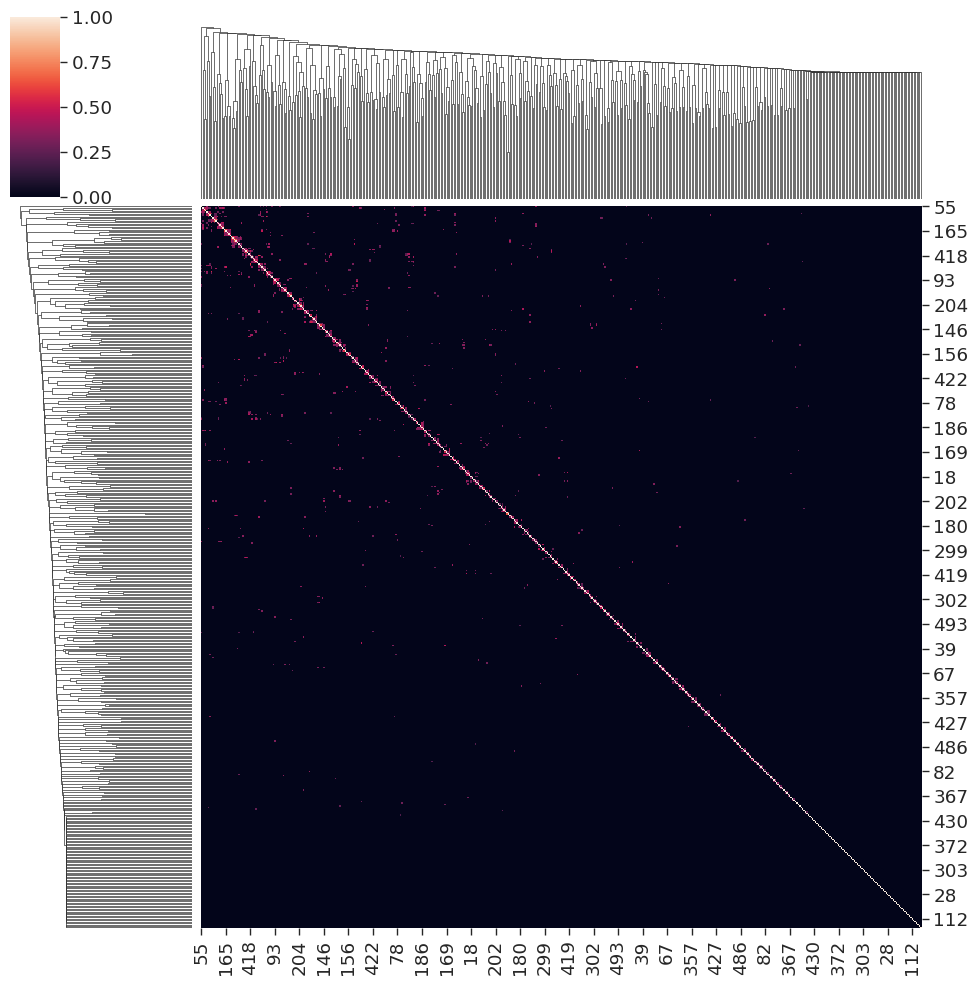

In [ ]:
sns.clustermap(M.toarray()[:500,:500])

In [ ]:
import sys
sys.getsizeof(M)

48

In [ ]:
# Initialize archetypes
model.initialize_archetypes()

Building kernel on X_glue
Computing diffusion components from X_glue for waypoint initialization ... 
Determing nearest neighbor graph...
Done.
Sampling waypoints ...
Done.
Selecting 1656 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [00:08<00:00,  8.53it/s]

Selecting 59 cells from greedy initialization.


In [ ]:
model.fit(min_iter=10, max_iter=200)

Randomly initialized A matrix.
Setting convergence threshold at 0.00525
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Starting iteration 30.
Completed iteration 30.
Starting iteration 40.
Completed iteration 40.
Converged after 48 iterations.


# Accessing results

## Model Convergence

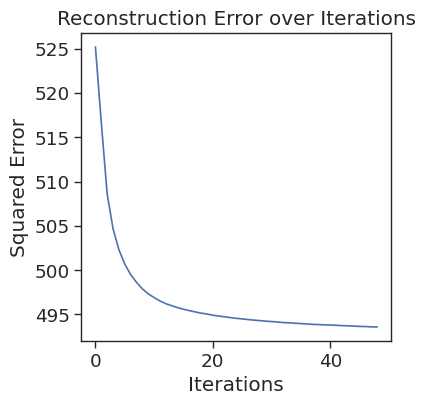

In [ ]:
# Check for convergence 
model.plot_convergence()

## SEACell Hard Assignments

These can be accessed as folows:
- in the modified anndata object in `.obs['SEAell']` 
- from the model using `.get_hard_assignments()` 


In [ ]:
adata.obs[['SEACell']].head()

,SEACell
index,
BT042_pons_2_TGATCAGTCCTACAAG-1,SEACell-1641
BT042_pons_2_TCTGGCTTCGAGAACG-1,SEACell-521
BT042_pons_2_GCAGCCAAGGACAAGA-1,SEACell-345
BT072_region_1_TTTGGTTTCGACACTA-1,SEACell-456
BT072_region_1_CTTCTAAGTTACCCTC-1,SEACell-345


In [ ]:
model.get_hard_assignments().head()

,SEACell
index,
BT042_pons_2_TGATCAGTCCTACAAG-1,SEACell-1641
BT042_pons_2_TCTGGCTTCGAGAACG-1,SEACell-521
BT042_pons_2_GCAGCCAAGGACAAGA-1,SEACell-345
BT072_region_1_TTTGGTTTCGACACTA-1,SEACell-456
BT072_region_1_CTTCTAAGTTACCCTC-1,SEACell-345


In [ ]:
adata.write(os.path.join(data_dir, "rna_malignant_seacells_postrun_downsampled.h5ad"), compression='gzip')

## SEACell Soft Assignments

Archetypal analysis returns soft assignments of cells to SEACells. The full assignment matrix can be accessed as the parameter ```model.A_```. However, the majority of single-cells are assigned to no more than 4 archetypes with non-trivial weight, so we return the top 5 metacell assignments as well as the corresponding assignment weights in the function ```model.get_soft_assignments()```

/scratch/24269124/ipykernel_1642572/2269664087.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)


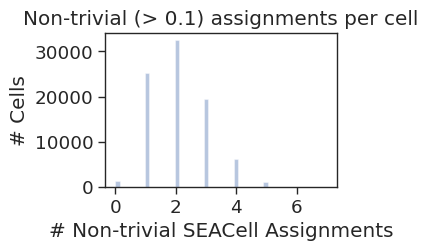

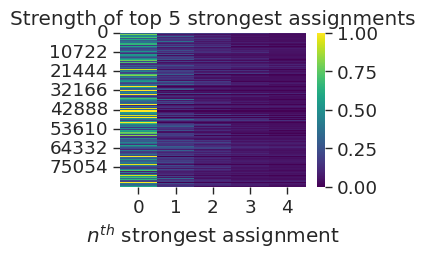

In [ ]:
plt.figure(figsize=(3,2))
sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)
plt.title(f'Non-trivial (> 0.1) assignments per cell')
plt.xlabel('# Non-trivial SEACell Assignments')
plt.ylabel('# Cells')
plt.show()

plt.figure(figsize=(3,2))
b = np.partition(model.A_.T, -5)    
sns.heatmap(np.sort(b[:,-5:])[:, ::-1], cmap='viridis', vmin=0)
plt.title('Strength of top 5 strongest assignments')
plt.xlabel('$n^{th}$ strongest assignment')
plt.show()


In [ ]:
labels,weights = model.get_soft_assignments()

In [ ]:
labels.head()

,0,1,2,3,4
index,,,,,
BT042_pons_2_TGATCAGTCCTACAAG-1,T20-90372_190AAO_ATTCCTATCACCTCGT-1,multiome_P-1701_S-1701_GAACCTGTCTATCGCC-1,T21-91160_MIMIC013_GCACATAGTAGATTGA-1,T21-91160_MIMIC013_TAGTGCAAGGTCTTTG-1,VUMC17_GTCTACCAGCCGGATA-1
BT042_pons_2_TCTGGCTTCGAGAACG-1,VUMC11_pons_TATATCCGTGTTGATC-1,T21-91074_MIMIC010_AAGGAATTCACCTGTC-1,T22-90003_MIMIC014_GTCATGAGTTGTACGT-1,T20-90372_190AAO_AGAAATGTCAAATGCC-1,T20-93623_348AAP_CCGATGGGTATAGGGC-1
BT042_pons_2_GCAGCCAAGGACAAGA-1,BT072_region_2_TCCATGCAGATGGTCG-1,BT072_region_2_ACAGAAAAGGGTAGCT-1,BT072_region_2_CTGGTCTTCAACGCTA-1,BT072_region_2_ATGGATCTCACTCTTA-1,T21-90868_448AAQ_TGTGATGCAGCTACTA-1
BT072_region_1_TTTGGTTTCGACACTA-1,multiome_P-1709_S-1709_GTCAATATCAAGCTAC-1,BT072_region_2_CTCCCAAGTTTACTTC-1,BT072_region_2_CTCATTAAGAGGTCAC-1,BT072_region_1_CTGCCATGTCCACATA-1,T21-90610_232AAQ_TAACACGGTCGTGCCA-1
BT072_region_1_CTTCTAAGTTACCCTC-1,BT072_region_2_TCCATGCAGATGGTCG-1,BT072_region_2_GATGCTACACGACGCT-1,BT072_region_2_TGGAGAGCACAATCTG-1,BT072_region_2_AATGAAGAGTTGCCCG-1,BT072_region_2_CTATCTAAGGCCTGCT-1


# Summarizing data

- `core.summarize_by_SEACell()`

Datasets can be summarized by SEACell by aggregating cells within each SEACell, summing over all raw data for all cells belonging to a SEACell. The output of this function is an anndata object of shape n_metacells x original_data_dimension. Data is unnormalized and raw aggregated counts are stored in `X`. Attributes associated with variables (.var) are copied over, but relevant per SEACell attributes must be manually copied, since certain attributes may need to be summed, or averaged etc, depending on the attribute.

By default, `adata.raw` is used for summarization. Other layers present in the anndata can be specified using the parameter `summarize_layer` parameter

In [ ]:
print(adata.X)

  (7, 0)	1.0
  (9, 0)	2.0
  (39, 0)	1.0
  (57, 0)	1.0
  (58, 0)	1.0
  (105, 0)	1.0
  (126, 0)	1.0
  (164, 0)	1.0
  (174, 0)	1.0
  (180, 0)	2.0
  (197, 0)	1.0
  (226, 0)	1.0
  (230, 0)	1.0
  (241, 0)	3.0
  (252, 0)	1.0
  (264, 0)	1.0
  (265, 0)	1.0
  (298, 0)	1.0
  (307, 0)	1.0
  (309, 0)	1.0
  (428, 0)	1.0
  (450, 0)	1.0
  (489, 0)	1.0
  (510, 0)	1.0
  (568, 0)	1.0
  :	:
  (85430, 19247)	1.0
  (85432, 19247)	1.0
  (85438, 19247)	1.0
  (85461, 19247)	1.0
  (85462, 19247)	1.0
  (85463, 19247)	1.0
  (85470, 19247)	1.0
  (85474, 19247)	2.0
  (85504, 19247)	1.0
  (85526, 19247)	1.0
  (85527, 19247)	1.0
  (85531, 19247)	1.0
  (85539, 19247)	1.0
  (85541, 19247)	1.0
  (85570, 19247)	1.0
  (85586, 19247)	1.0
  (85590, 19247)	1.0
  (85593, 19247)	1.0
  (85594, 19247)	1.0
  (85595, 19247)	1.0
  (85598, 19247)	1.0
  (85611, 19247)	1.0
  (85628, 19247)	1.0
  (85635, 19247)	1.0
  (85701, 19247)	1.0


In [ ]:
adata.X.data

array([1., 2., 1., ..., 1., 1., 1.])

In [ ]:
adata.layers['counts'] = adata.X.copy()

In [ ]:
SEACell_ad = SEACells.core.summarize_by_SEACell(adata, SEACells_label='SEACell', summarize_layer='counts')
SEACell_ad

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [09:38<00:00,  2.97it/s]


AnnData object with n_obs × n_vars = 1715 × 19248
    layers: 'raw'

In [ ]:
import gc
gc.collect()

45942

## Normalization

Normalization of metacell data can be performed using the `sc.pp.normalize_total` and `sc.pp.log1p` functions

# Evaluating Results

We provide several methods for evaluating SEACell assignments:

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/SEACells-0.3.3-py3.9.egg/SEACells/plot.py:121: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(label_df.groupby('SEACell').count().iloc[:, 0], bins=bins)


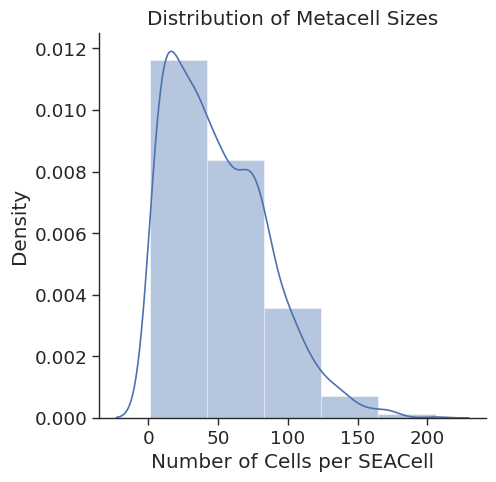

,size
SEACell,
SEACell-0,115
SEACell-1,173
SEACell-2,105
SEACell-3,92
SEACell-4,103
...,...
SEACell-1710,16
SEACell-1711,31
SEACell-1712,35


In [ ]:
SEACells.plot.plot_SEACell_sizes(adata, bins=5)

## Quantifying Results

SEACells also implements methods for visualizing the results of the SEACells algorithm 
    <ul> 
        <li>```.compute_celltype_purity(adata, col_name)``` computes the purity of different celltype labels within a SEACell metacell. Typically, col_name='celltype' or similar. Returns a pd.DataFrame of length n_SEACells.
        <li>```.compactness(adata, low_dim_embedding)``` computes the per-SEAcell variance in diffusion components. ```low_dim_embedding``` is a string specifying the low dimensional embedding with which diffusion components are calculated, typically 'X_pca' for RNA or 'X_svd' for ATAC. Lower values of compactness suggest more compact/lower variance metacells.
        <li>```separation(adata, low_dim_embedding,nth_nbr=1,cluster=None)``` computes the diffusion distance between a SEACell and its ```nth_nbr```. As before, ```low_dim_embedding``` is a string specifying the low dimensional embedding with which diffusion components are calculated, typically 'X_pca' for RNA or 'X_svd' for ATAC. If ```cluster``` is provided as a string, e.g. 'celltype', nearest neighbors are restricted to have the same celltype value.  Higher values of separation suggest better distinction between metacells.
    </ul>
    


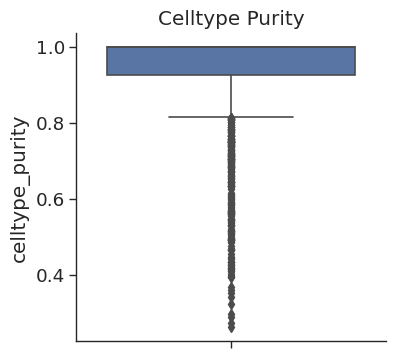

,celltype,celltype_purity
SEACell,,
SEACell-0,MP 5,0.939130
SEACell-1,MP 7,0.682081
SEACell-2,MP 2,1.000000
SEACell-3,MP 12,0.641304
SEACell-4,MP 4,0.514563


In [ ]:
SEACell_purity = SEACells.evaluate.compute_celltype_purity(adata, 'celltype')

plt.figure(figsize=(4,4))
sns.boxplot(data=SEACell_purity, y='celltype_purity')
plt.title('Celltype Purity')
sns.despine()
plt.show()
plt.close()

SEACell_purity.head()

Determing nearest neighbor graph...


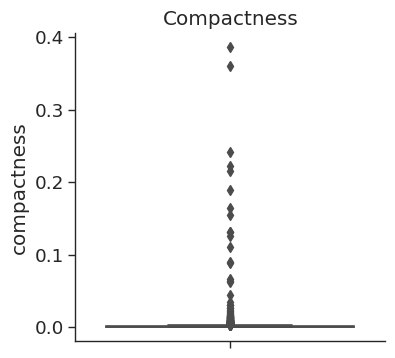

,compactness
SEACell,
SEACell-0,0.034214
SEACell-1,0.000597
SEACell-2,0.000696
SEACell-3,0.000811
SEACell-4,0.001103


In [ ]:
compactness = SEACells.evaluate.compactness(adata, 'X_glue')

plt.figure(figsize=(4,4))
sns.boxplot(data=compactness, y='compactness')
plt.title('Compactness')
sns.despine()
plt.show()
plt.close()

compactness.head()

Determing nearest neighbor graph...


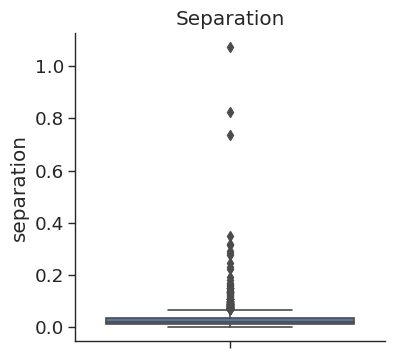

,separation
SEACell,
SEACell-0,0.065621
SEACell-1,0.025870
SEACell-2,0.026303
SEACell-3,0.041059
SEACell-4,0.037555


In [ ]:
separation = SEACells.evaluate.separation(adata, 'X_glue',nth_nbr=1)

plt.figure(figsize=(4,4))
sns.boxplot(data=separation, y='separation')
plt.title('Separation')
sns.despine()
plt.show()
plt.close()

separation.head()

In [ ]:
SEACell_ad.write(os.path.join(data_dir, "rna_seacells_downsampled.h5ad"), compression = 'gzip')